# AutoEIT — Breakfast / Snow Sentence Analysis
Locates a version-specific EIT item in every recording's transcription:
- **version_a**: "Hay mucha gente que no toma nada para el desayuno."
- **version_b**: "Hay muchas personas que se quedan en casa si nieva mucho."

As with the volleyball-sentence analysis, Whisper transcripts vary a lot from the canonical
stimulus, so matching is done via a distinctive keyword substring per version rather than an
exact string match. If the sentence is matched in more than one item within a recording, the
**last** matching item (highest item index) is used for the index-distribution plot, and the
recording is also tracked separately as a "double occurrence" case. version_a and version_b are
processed independently throughout.

For every recording, this notebook also persists the matched indices back into
`summary.json` under `last_spanish_sentence` (the English-sentence equivalent lives under
`last_english_item`, written by `analyze_volleyball_sentence.ipynb`).

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Config

In [2]:
TRANSCRIBED_ROOT = Path("../../data/transcribed/v1")
VERSIONS = ["version_a", "version_b"]

# Canonical stimulus per version, matched via distinctive keyword combinations rather than an
# exact string, since ASR transcripts vary widely (typos, dropped/added words, garbled endings).
# Each entry in "keyword_sets" is a list of keywords that must ALL be present (AND); a text
# matches if ANY keyword set matches (OR). Sets were chosen by checking data/stimuli_sentences_*
# to confirm the keywords don't appear in any other stimulus sentence for that version.
TARGET_SENTENCES = {
    "version_a": {
        "canonical": "Hay mucha gente que no toma nada para el desayuno.",
        # "desayuno" and "gente" are each unique to this stimulus among version_a sentences;
        # matching on either catches cases where one of the two words got garbled by ASR.
        "keyword_sets": [["desayuno"], ["gente"]],
    },
    "version_b": {
        "canonical": "Hay muchas personas que se quedan en casa si nieva mucho.",
        # "niev" (nieva/nieve/nievan) is often mis-transcribed into unrelated words, so fall back
        # to "persona"+"casa" together, which is also unique among version_b stimuli.
        "keyword_sets": [["niev"], ["persona", "casa"]],
    },
}

# Same thresholds as analyze_anomalies.ipynb / analyze_volleyball_sentence.ipynb
LOW_THRESHOLD = 30   # item_count < LOW_THRESHOLD -> short anomaly
HIGH_THRESHOLD = 40  # item_count > HIGH_THRESHOLD -> long anomaly


def matches_sentence(text: str, version: str) -> bool:
    t = text.lower()
    return any(
        all(kw in t for kw in keyword_set)
        for keyword_set in TARGET_SENTENCES[version]["keyword_sets"]
    )


def categorize(item_count: int) -> str:
    if item_count > HIGH_THRESHOLD:
        return "long anomaly"
    if item_count < LOW_THRESHOLD:
        return "short anomaly"
    return "good"

## Scan transcriptions for the target sentence
For each recording, find every item whose text matches its version's target sentence, keep the
last matching item for the index-distribution plot, and flag recordings where the sentence
occurs more than once.

In [3]:
def scan_version(version: str) -> pd.DataFrame:
    version_dir = TRANSCRIBED_ROOT / version
    rows = []
    for summary_path in sorted(version_dir.glob("*/summary.json")):
        with open(summary_path, encoding="utf-8") as f:
            s = json.load(f)
        matched_items = [it for it in s["items"] if matches_sentence(it["text"], version)]
        if not matched_items:
            rows.append({
                "recording": s["recording"],
                "version": s["version"],
                "item_count": s["item_count"],
                "found": False,
                "match_count": 0,
                "matched_indices": [],
                "last_index": None,
            })
            continue
        matched_items = sorted(matched_items, key=lambda it: it["index"])
        rows.append({
            "recording": s["recording"],
            "version": s["version"],
            "item_count": s["item_count"],
            "found": True,
            "match_count": len(matched_items),
            "matched_indices": [it["index"] for it in matched_items],
            "last_index": matched_items[-1]["index"],
        })
    return pd.DataFrame(rows)


results = {version: scan_version(version) for version in VERSIONS}

## Persist results back into each recording's summary.json
For every recording, add `last_spanish_sentence`: list of item indices where the sentence was
matched (empty if not found, more than one entry if the sentence occurred more than once).
This does not touch `last_english_item` or `category`, which are written by
`analyze_volleyball_sentence.ipynb`.

In [4]:
for version in VERSIONS:
    df = results[version]
    version_dir = TRANSCRIBED_ROOT / version
    for _, row in df.iterrows():
        summary_path = version_dir / row["recording"] / "summary.json"
        with open(summary_path, encoding="utf-8") as f:
            s = json.load(f)
        s["last_spanish_sentence"] = row["matched_indices"]
        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(s, f, ensure_ascii=False, indent=2)
    print(f"{version}: updated {len(df)} summary.json file(s)")

version_a: updated 102 summary.json file(s)


version_b: updated 103 summary.json file(s)


## Statistics — how many recordings contained the sentence

In [5]:
for version in VERSIONS:
    df = results[version]
    n_total = len(df)
    n_found = int(df["found"].sum())
    n_double = int((df["match_count"] > 1).sum())
    print(f"=== {version} — \"{TARGET_SENTENCES[version]['canonical']}\" ===")
    print(f"  recordings scanned:        {n_total}")
    print(f"  sentence found in:         {n_found}  ({n_found / n_total:.1%})")
    print(f"  not found in:              {n_total - n_found}")
    print(f"  found more than once in:   {n_double}")
    print()

=== version_a — "Hay mucha gente que no toma nada para el desayuno." ===
  recordings scanned:        102
  sentence found in:         89  (87.3%)
  not found in:              13
  found more than once in:   11

=== version_b — "Hay muchas personas que se quedan en casa si nieva mucho." ===
  recordings scanned:        103
  sentence found in:         74  (71.8%)
  not found in:              29
  found more than once in:   10



## Recordings where the sentence was not found
Listed for reference — these are likely anomalous recordings (missing or heavily garbled items).

In [6]:
for version in VERSIONS:
    df = results[version]
    missing = df[~df["found"]][["recording", "item_count"]].reset_index(drop=True)
    print(f"=== {version}: {len(missing)} recording(s) without the sentence ===")
    display(missing)

=== version_a: 13 recording(s) without the sentence ===


,recording,item_count
0,038009_EIT-1A,29
1,038012_EIT-2A,72
2,038019_EIT-1A,37
3,038021_EIT-1A,32
4,038022_EIT-2A,37
5,038023_EIT-1A,37
6,038024_EIT-2A,35
7,038047_EITv-1A.mp3,37
8,038049_EIT-2A,21
9,038053_EITv-2A,39


=== version_b: 29 recording(s) without the sentence ===


,recording,item_count
0,038.073_EITv1B,36
1,038.087_EIT2_vB,60
2,038.089_EITv-1B,40
3,038.100_EIT-v2B,38
4,038.106_EITv-2B,37
5,038002_EIT-1B,35
6,038006_EIT-1B,37
7,038010_EIT-1B,35
8,038014_EIT-1B,39
9,038017_EIT-2B,37


## Distribution of item index where the sentence occurred
Uses the last matching item per recording when the sentence appears more than once.

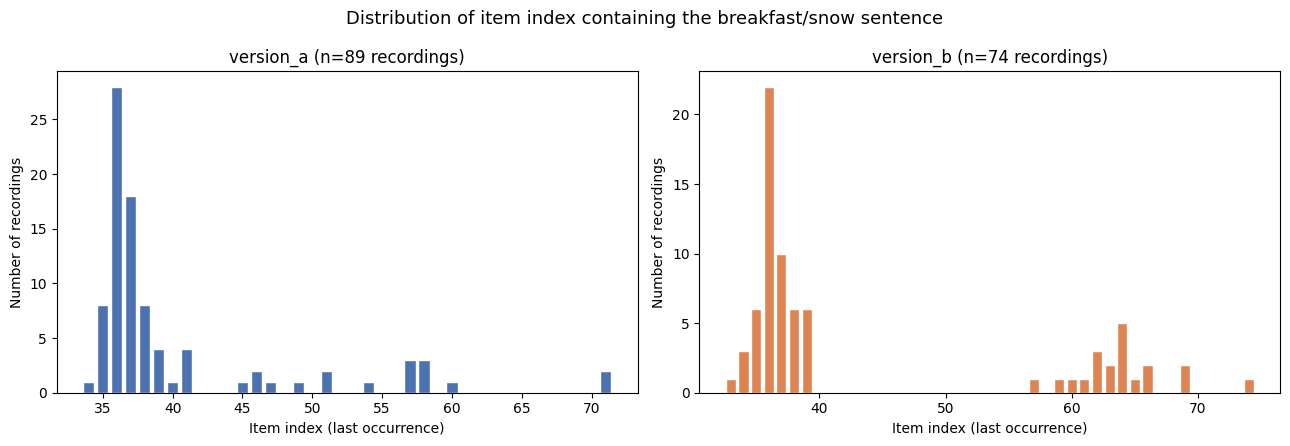

In [7]:
colors = {"version_a": "#4C72B0", "version_b": "#DD8452"}

fig, axes = plt.subplots(1, len(VERSIONS), figsize=(13, 4.5), sharey=False)

for ax, version in zip(axes, VERSIONS):
    df = results[version]
    found = df[df["found"]]
    counts = found["last_index"].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=colors[version], edgecolor="white")
    ax.set_title(f"{version} (n={len(found)} recordings)", fontsize=12)
    ax.set_xlabel("Item index (last occurrence)")
    ax.set_ylabel("Number of recordings")

fig.suptitle("Distribution of item index containing the breakfast/snow sentence", fontsize=13)
fig.tight_layout()
plt.savefig("../plots/breakfast_snow_sentence_index_distribution.png", dpi=150)
plt.show()

## Recordings where the sentence occurred twice
For these, check whether the recording falls into the "long anomaly" (> 40 items), "good"
(30–40 items), or "short anomaly" (< 30 items) category.

In [8]:
for version in VERSIONS:
    df = results[version]
    doubles = df[df["match_count"] > 1].copy()
    doubles["category"] = doubles["item_count"].apply(categorize)
    print(f"=== {version}: {len(doubles)} recording(s) with the sentence twice ===")
    display(
        doubles[["recording", "item_count", "matched_indices", "category"]]
        .sort_values("item_count", ascending=False)
        .reset_index(drop=True)
    )

=== version_a: 11 recording(s) with the sentence twice ===


,recording,item_count,matched_indices,category
0,038.087_EIT2_vA,60,"[57, 58]",long anomaly
1,038.095_EIT2_vA,60,"[57, 58]",long anomaly
2,038.082_EIT1_vA,59,"[56, 57]",long anomaly
3,038028_EITv-2A,56,"[53, 54]",long anomaly
4,038.097_EIT2_vA,53,"[50, 51]",long anomaly
5,038.102_EIT1_vA,49,"[46, 47]",long anomaly
6,038.096_EIT1_vA,48,"[45, 46]",long anomaly
7,038.107_EIT2_vA,48,"[45, 46]",long anomaly
8,038.084_EIT1_vA,47,"[44, 45]",long anomaly
9,038018_EIT-2A,39,"[36, 38]",good


=== version_b: 10 recording(s) with the sentence twice ===


,recording,item_count,matched_indices,category
0,038.084_EIT2_vB,71,"[68, 69]",long anomaly
1,038028_EITv-1B,70,"[65, 66]",long anomaly
2,038.093_EIT1_vB,66,"[63, 64]",long anomaly
3,038.087_EIT1_vB,66,"[63, 64]",long anomaly
4,038.087_EIT1_vB (1),66,"[63, 64]",long anomaly
5,038.082_EIT2_vB,64,"[61, 62]",long anomaly
6,038.102_EIT2_vB,64,"[61, 62]",long anomaly
7,038.105_EIT1_vB,63,"[61, 62]",long anomaly
8,038.085_EIT1_vB,62,"[60, 61]",long anomaly
9,038031_EIT-2B,37,"[33, 36]",good


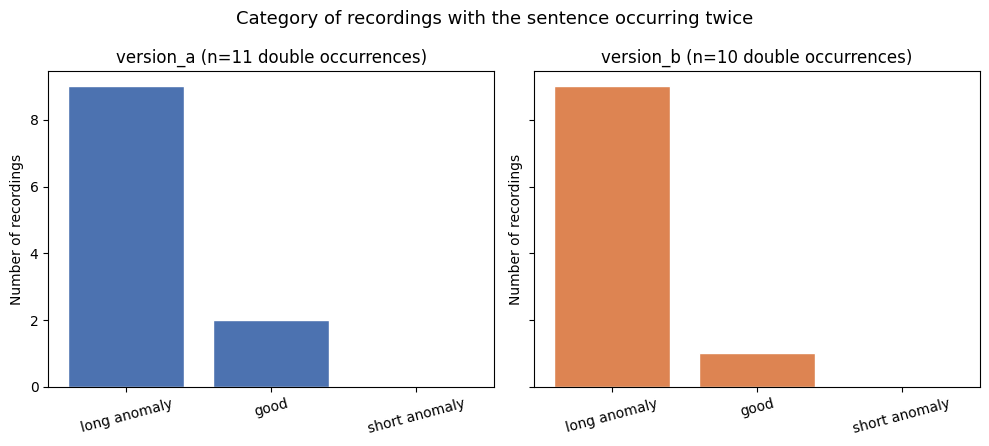

In [9]:
category_order = ["long anomaly", "good", "short anomaly"]

fig, axes = plt.subplots(1, len(VERSIONS), figsize=(10, 4.5), sharey=True)

for ax, version in zip(axes, VERSIONS):
    df = results[version]
    doubles = df[df["match_count"] > 1].copy()
    doubles["category"] = doubles["item_count"].apply(categorize)
    counts = doubles["category"].value_counts().reindex(category_order, fill_value=0)
    ax.bar(counts.index, counts.values, color=colors[version], edgecolor="white")
    ax.set_title(f"{version} (n={len(doubles)} double occurrences)", fontsize=12)
    ax.set_ylabel("Number of recordings")
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Category of recordings with the sentence occurring twice", fontsize=13)
fig.tight_layout()
plt.savefig("../plots/breakfast_snow_sentence_double_occurrence_category.png", dpi=150)
plt.show()